# 第7弾: 複合戦略ポートフォリオ（シリーズ集大成）

## 戦略概要

- **ポートフォリオ構成**: 第3弾アダプティブRSI（順張りフィルタ）+ 第1弾ミーンリバージョン（逆張り）
- **配分方法**: 均等配分 / 逆ボラティリティ加重 / 最小分散（MPT）の3種を比較
- **問い**: 相関の低い戦略を組み合わせることでドローダウンは抑制できるか

| 配分方法 | 概要 |
|---------|------|
| 均等配分 | 各戦略に50%ずつ配分 |
| 逆ボラティリティ加重 | PnLの標準偏差に反比例して配分。ボラが低い戦略ほど多く配分 |
| 最小分散（MPT） | 共分散行列を使ってポートフォリオ全体の分散を最小化する配分を求める |

## 検証対象

- USD/JPY（5分足、スプレッド片道0.002円）
- ETH/JPY（5分足、スプレッド片道=終値平均×0.00005）

## 1. セットアップ

In [1]:
!pip install japanize-matplotlib scipy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 18.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import datetime, timedelta
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

import japanize_matplotlib

print("ライブラリ読み込み完了")

ライブラリ読み込み完了


## 2. GMO Coin KLine API からデータ取得

In [3]:
ENDPOINTS = {
    "fx":     "https://forex-api.coin.z.com/public/v1/klines",
    "crypto": "https://api.coin.z.com/public/v1/klines",
}

SYMBOL_CONFIG = {
    "USD_JPY": {"api": "fx",     "priceType": "BID"},
    "ETH_JPY": {"api": "crypto", "priceType": None},
}

def fetch_gmo_kline(symbol, interval="5min", days_back=365):
    config = SYMBOL_CONFIG.get(symbol)
    if config is None:
        print(f"未定義のシンボル: {symbol}")
        return pd.DataFrame()

    base_url = ENDPOINTS[config["api"]]
    all_data = []
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days_back)
    current_date = start_date

    print(f"{symbol} の{interval}データを取得中...")
    print(f"  API: {config['api']} ({base_url})")
    print(f"  期間: {start_date.strftime('%Y-%m-%d')} -> {end_date.strftime('%Y-%m-%d')}")

    request_count = 0
    error_count = 0

    while current_date <= end_date:
        date_str = current_date.strftime("%Y%m%d")
        params = {"symbol": symbol, "interval": interval, "date": date_str}
        if config["priceType"]:
            params["priceType"] = config["priceType"]

        try:
            resp = requests.get(base_url, params=params, timeout=10)
            data = resp.json()
            if data.get("status") == 0 and data.get("data"):
                for c in data["data"]:
                    all_data.append({
                        "datetime": pd.to_datetime(
                            int(c["openTime"]), unit="ms", utc=True
                        ).tz_convert("Asia/Tokyo"),
                        "open":   float(c["open"]),
                        "high":   float(c["high"]),
                        "low":    float(c["low"]),
                        "close":  float(c["close"]),
                        "volume": float(c.get("volume", 0)),
                    })
                request_count += 1
        except Exception as e:
            error_count += 1
            if error_count <= 3:
                print(f"  {date_str}: {e}")

        current_date += timedelta(days=1)
        if request_count % 5 == 0 and request_count > 0:
            time.sleep(1)

    if not all_data:
        print(f"データ取得失敗: {symbol}")
        return pd.DataFrame()

    df = pd.DataFrame(all_data)
    df = df.sort_values("datetime").drop_duplicates(subset="datetime").reset_index(drop=True)

    print(f"{len(df):,}本取得 ({request_count}リクエスト)")
    print(f"  最初: {df['datetime'].iloc[0]}")
    print(f"  最後: {df['datetime'].iloc[-1]}")
    return df

print("データ取得関数を定義")

データ取得関数を定義


### USD/JPY データ取得

In [4]:
df_usdjpy = fetch_gmo_kline("USD_JPY", interval="5min", days_back=365)
df_usdjpy.head()

USD_JPY の5minデータを取得中...
  API: fx (https://forex-api.coin.z.com/public/v1/klines)
  期間: 2025-04-08 -> 2026-04-08
74,033本取得 (260リクエスト)
  最初: 2025-04-08 06:00:00+09:00
  最後: 2026-04-08 14:35:00+09:00


,datetime,open,high,low,close,volume
0,2025-04-08 06:00:00+09:00,147.785,147.895,147.785,147.862,0.0
1,2025-04-08 06:05:00+09:00,147.862,147.886,147.862,147.882,0.0
2,2025-04-08 06:10:00+09:00,147.882,147.884,147.880,147.880,0.0
3,2025-04-08 06:15:00+09:00,147.880,147.884,147.850,147.852,0.0
4,2025-04-08 06:20:00+09:00,147.852,147.876,147.850,147.872,0.0


### ETH/JPY データ取得

In [5]:
df_eth = fetch_gmo_kline("ETH_JPY", interval="5min", days_back=365)
df_eth.head()

ETH_JPY の5minデータを取得中...
  API: crypto (https://api.coin.z.com/public/v1/klines)
  期間: 2025-04-08 -> 2026-04-08
103,233本取得 (366リクエスト)
  最初: 2025-04-08 06:00:00+09:00
  最後: 2026-04-08 14:35:00+09:00


,datetime,open,high,low,close,volume
0,2025-04-08 06:00:00+09:00,232174.0,232280.0,231400.0,231451.0,41.28
1,2025-04-08 06:05:00+09:00,231434.0,231475.0,230360.0,230967.0,18.08
2,2025-04-08 06:10:00+09:00,231182.0,231815.0,231182.0,231815.0,6.46
3,2025-04-08 06:15:00+09:00,231867.0,232290.0,231621.0,232181.0,6.90
4,2025-04-08 06:20:00+09:00,232134.0,232135.0,230725.0,231187.0,12.48


## 3. 各戦略のトレードログ生成

第1弾と第3弾を再現してトレードログ（日次PnL系列）を生成する。
ポートフォリオの配分計算には日次PnL系列を使用する。

In [6]:
def calc_rsi(series, period=14):
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period).mean()
    rs  = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


# =====================================================
# 第1弾: ミーンリバージョン（RSI + ボリンジャーバンド）
# =====================================================
def run_mean_reversion(df, rsi_oversold=30, rsi_overbought=70,
                       bb_period=20, bb_sigma=2.0, spread=0.0):
    """第1弾ミーンリバージョン戦略。トレードログを返す。"""
    rsi   = calc_rsi(df["close"])
    ma    = df["close"].rolling(bb_period).mean()
    std   = df["close"].rolling(bb_period).std()
    upper = ma + bb_sigma * std
    lower = ma - bb_sigma * std

    df2 = pd.DataFrame({
        "datetime": df["datetime"],
        "close": df["close"],
        "rsi": rsi, "upper": upper, "lower": lower, "ma": ma,
    }).dropna().reset_index(drop=True)

    close  = df2["close"].to_numpy()
    rsi_   = df2["rsi"].to_numpy()
    upper_ = df2["upper"].to_numpy()
    lower_ = df2["lower"].to_numpy()
    ma_    = df2["ma"].to_numpy()
    dts    = df2["datetime"].to_numpy()

    position = 0
    entry_price = 0.0
    entry_time  = None
    trades = []

    for i in range(1, len(close)):
        c = close[i]
        r = rsi_[i]

        if position == 0:
            if r < rsi_oversold and c < lower_[i]:
                position    = 1
                entry_price = c + spread
                entry_time  = dts[i]
            elif r > rsi_overbought and c > upper_[i]:
                position    = -1
                entry_price = c - spread
                entry_time  = dts[i]
        elif position == 1 and c > ma_[i]:
            trades.append({"entry_time": entry_time, "exit_time": dts[i],
                           "pnl": (c - spread) - entry_price})
            position = 0
        elif position == -1 and c < ma_[i]:
            trades.append({"entry_time": entry_time, "exit_time": dts[i],
                           "pnl": entry_price - (c + spread)})
            position = 0

    return pd.DataFrame(trades)


# =====================================================
# 第3弾: アダプティブRSI（マルチタイムフレーム）
# =====================================================
def run_adaptive_rsi(df, rsi_oversold=30, rsi_overbought=70,
                     rsi_exit=50, htf_rule="1h", spread=0.0):
    """第3弾アダプティブRSI戦略。トレードログを返す。"""
    df = df.copy()
    df["rsi_5m"] = calc_rsi(df["close"])

    htf = df.set_index("datetime")["close"].resample(htf_rule).ohlc().dropna().reset_index()
    htf["htf_rsi"] = calc_rsi(htf["close"])
    htf = htf[["datetime", "htf_rsi"]].dropna()

    df = pd.merge_asof(
        df.sort_values("datetime"),
        htf.sort_values("datetime"),
        on="datetime", direction="backward",
        suffixes=("", "_tmp")
    ).dropna(subset=["rsi_5m", "htf_rsi"]).reset_index(drop=True)

    close     = df["close"].to_numpy()
    rsi_5m    = df["rsi_5m"].to_numpy()
    htf_rsi   = df["htf_rsi"].to_numpy()
    dts       = df["datetime"].to_numpy()

    position = 0
    entry_price = 0.0
    entry_time  = None
    trades = []

    for i in range(1, len(close)):
        c   = close[i]
        r   = rsi_5m[i]
        htf = htf_rsi[i]

        if position == 0:
            if r < rsi_oversold and htf > 50:
                position    = 1
                entry_price = c + spread
                entry_time  = dts[i]
            elif r > rsi_overbought and htf < 50:
                position    = -1
                entry_price = c - spread
                entry_time  = dts[i]
        elif position == 1 and r > rsi_exit:
            trades.append({"entry_time": entry_time, "exit_time": dts[i],
                           "pnl": (c - spread) - entry_price})
            position = 0
        elif position == -1 and r < rsi_exit:
            trades.append({"entry_time": entry_time, "exit_time": dts[i],
                           "pnl": entry_price - (c + spread)})
            position = 0

    return pd.DataFrame(trades)


def trades_to_daily_pnl(trades_df):
    """トレードログを日次PnL系列に変換"""
    if trades_df.empty:
        return pd.Series(dtype=float)
    tdf = trades_df.copy()
    tdf["date"] = pd.to_datetime(tdf["exit_time"]).dt.date
    return tdf.groupby("date")["pnl"].sum()


print("戦略関数を定義")

戦略関数を定義


### USD/JPY トレードログ生成

In [7]:
# 第1弾: ミーンリバージョン
mr_trades_usdjpy = run_mean_reversion(df_usdjpy, spread=0.002)
mr_daily_usdjpy  = trades_to_daily_pnl(mr_trades_usdjpy)

# 第3弾: アダプティブRSI
ar_trades_usdjpy = run_adaptive_rsi(df_usdjpy, spread=0.002)
ar_daily_usdjpy  = trades_to_daily_pnl(ar_trades_usdjpy)

print(f"MR: {len(mr_trades_usdjpy)}件  AR: {len(ar_trades_usdjpy)}件")

# 日次PnLの相関を確認
daily = pd.DataFrame({"MR": mr_daily_usdjpy, "AR": ar_daily_usdjpy}).fillna(0)
print(f"日次PnL相関係数: {daily['MR'].corr(daily['AR']):.4f}")

MR: 952件  AR: 233件
日次PnL相関係数: 0.3126


### ETH/JPY トレードログ生成

In [8]:
eth_spread = df_eth["close"].mean() * 0.00005
print(f"ETH/JPY 推定スプレッド: {eth_spread:.0f}円")

mr_trades_eth = run_mean_reversion(df_eth, spread=eth_spread)
mr_daily_eth  = trades_to_daily_pnl(mr_trades_eth)

ar_trades_eth = run_adaptive_rsi(df_eth, spread=eth_spread)
ar_daily_eth  = trades_to_daily_pnl(ar_trades_eth)

print(f"MR: {len(mr_trades_eth)}件  AR: {len(ar_trades_eth)}件")

daily_eth = pd.DataFrame({"MR": mr_daily_eth, "AR": ar_daily_eth}).fillna(0)
print(f"日次PnL相関係数: {daily_eth['MR'].corr(daily_eth['AR']):.4f}")

ETH/JPY 推定スプレッド: 23円
MR: 1350件  AR: 287件
日次PnL相関係数: 0.3070


## 4. ポートフォリオの配分計算

### 3種の配分方法

**均等配分**: 各戦略50%ずつ。最もシンプルなベースライン。

**逆ボラティリティ加重**: 各戦略のPnLの標準偏差（ボラティリティ）に反比例して配分。
ボラが高い戦略ほど比重を下げることで、全体のリスクを均等にする。

**最小分散（MPT）**: 現代ポートフォリオ理論（Modern Portfolio Theory）に基づき、
共分散行列から全体の分散を最小化する配分を数値最適化で求める。

In [9]:
def calc_weights(daily_df):
    """
    3種の配分を計算して返す。
    daily_df: 列が戦略名、行が日付の日次PnL DataFrame
    """
    n = len(daily_df.columns)

    # 1. 均等配分
    equal_w = np.array([1 / n] * n)

    # 2. 逆ボラティリティ加重
    vols = daily_df.std()
    inv_vol = 1 / vols
    inv_vol_w = (inv_vol / inv_vol.sum()).values

    # 3. 最小分散（MPT）
    cov = daily_df.cov().values

    def portfolio_variance(w):
        return w @ cov @ w

    constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
    bounds = [(0, 1)] * n
    init_w = equal_w

    result = minimize(portfolio_variance, init_w,
                      method="SLSQP",
                      bounds=bounds,
                      constraints=constraints)
    min_var_w = result.x

    print("配分結果:")
    for name, ew, ivw, mvw in zip(daily_df.columns, equal_w, inv_vol_w, min_var_w):
        print(f"  {name}: 均等={ew:.3f}  逆ボラ={ivw:.3f}  最小分散={mvw:.3f}")

    return {"equal": equal_w, "inv_vol": inv_vol_w, "min_var": min_var_w}


def calc_portfolio_pnl(daily_df, weights):
    """配分ウェイトを適用したポートフォリオの日次PnLを返す"""
    return daily_df @ weights


def calc_stats(daily_pnl, label=""):
    """日次PnL系列から各種統計を計算して表示"""
    equity = daily_pnl.cumsum()
    max_dd = (equity - equity.cummax()).min()
    total  = daily_pnl.sum()
    wins   = (daily_pnl > 0).sum()
    losses = (daily_pnl < 0).sum()
    gp = daily_pnl[daily_pnl > 0].sum()
    gl = daily_pnl[daily_pnl < 0].abs().sum()
    pf = gp / gl if gl > 0 else float("inf")
    sharpe = daily_pnl.mean() / daily_pnl.std() * np.sqrt(252) if daily_pnl.std() > 0 else 0

    print(f"  [{label}]")
    print(f"    勝ち日/負け日: {wins}/{losses}  総損益: {total:.4f}  PF: {pf:.3f}")
    print(f"    最大DD: {max_dd:.4f}  シャープ(年率): {sharpe:.3f}")
    return {"label": label, "total_pnl": total, "pf": pf,
            "max_dd": max_dd, "sharpe": sharpe}


print("ポートフォリオ計算関数を定義")

ポートフォリオ計算関数を定義


### USD/JPY ポートフォリオ配分計算

In [10]:
print("=== USD/JPY ===")
daily_usdjpy = pd.DataFrame({"MR": mr_daily_usdjpy, "AR": ar_daily_usdjpy}).fillna(0)
weights_usdjpy = calc_weights(daily_usdjpy)

=== USD/JPY ===
配分結果:
  MR: 均等=0.500  逆ボラ=0.348  最小分散=0.125
  AR: 均等=0.500  逆ボラ=0.652  最小分散=0.875


### ETH/JPY ポートフォリオ配分計算

In [11]:
print("=== ETH/JPY ===")
daily_eth = pd.DataFrame({"MR": mr_daily_eth, "AR": ar_daily_eth}).fillna(0)
weights_eth = calc_weights(daily_eth)

=== ETH/JPY ===
配分結果:
  MR: 均等=0.500  逆ボラ=0.301  最小分散=0.058
  AR: 均等=0.500  逆ボラ=0.699  最小分散=0.942


## 5. バックテスト

### USD/JPY バックテスト

In [12]:
print("=== USD/JPY バックテスト ===")

# 単体成績
print("\n単体成績:")
stats_mr_usd = calc_stats(daily_usdjpy["MR"], "MR単体")
stats_ar_usd = calc_stats(daily_usdjpy["AR"], "AR単体")

# ポートフォリオ成績
print("\nポートフォリオ成績:")
pf_eq_usd  = calc_portfolio_pnl(daily_usdjpy, weights_usdjpy["equal"])
pf_iv_usd  = calc_portfolio_pnl(daily_usdjpy, weights_usdjpy["inv_vol"])
pf_mv_usd  = calc_portfolio_pnl(daily_usdjpy, weights_usdjpy["min_var"])

stats_eq_usd = calc_stats(pf_eq_usd, "均等配分")
stats_iv_usd = calc_stats(pf_iv_usd, "逆ボラティリティ加重")
stats_mv_usd = calc_stats(pf_mv_usd, "最小分散（MPT）")

=== USD/JPY バックテスト ===

単体成績:
  [MR単体]
    勝ち日/負け日: 154/136  総損益: -3.8420  PF: 0.910
    最大DD: -11.7870  シャープ(年率): -0.534
  [AR単体]
    勝ち日/負け日: 150/29  総損益: 22.5330  PF: 5.765
    最大DD: -2.1470  シャープ(年率): 5.857

ポートフォリオ成績:
  [均等配分]
    勝ち日/負け日: 168/123  総損益: 9.3455  PF: 1.459
    最大DD: -3.3125  シャープ(年率): 2.041
  [逆ボラティリティ加重]
    勝ち日/負け日: 177/114  総損益: 13.3417  PF: 1.942
    最大DD: -2.1808  シャープ(年率): 3.285
  [最小分散（MPT）]
    勝ち日/負け日: 195/96  総損益: 19.2381  PF: 3.621
    最大DD: -2.1060  シャープ(年率): 5.136


### ETH/JPY バックテスト

In [13]:
print("=== ETH/JPY バックテスト ===")

print("\n単体成績:")
stats_mr_eth = calc_stats(daily_eth["MR"], "MR単体")
stats_ar_eth = calc_stats(daily_eth["AR"], "AR単体")

print("\nポートフォリオ成績:")
pf_eq_eth  = calc_portfolio_pnl(daily_eth, weights_eth["equal"])
pf_iv_eth  = calc_portfolio_pnl(daily_eth, weights_eth["inv_vol"])
pf_mv_eth  = calc_portfolio_pnl(daily_eth, weights_eth["min_var"])

stats_eq_eth = calc_stats(pf_eq_eth, "均等配分")
stats_iv_eth = calc_stats(pf_iv_eth, "逆ボラティリティ加重")
stats_mv_eth = calc_stats(pf_mv_eth, "最小分散（MPT）")

=== ETH/JPY バックテスト ===

単体成績:
  [MR単体]
    勝ち日/負け日: 218/146  総損益: -54161.4964  PF: 0.954
    最大DD: -176426.9976  シャープ(年率): -0.270
  [AR単体]
    勝ち日/負け日: 167/46  総損益: 439396.7797  PF: 3.523
    最大DD: -34326.6755  シャープ(年率): 5.070

ポートフォリオ成績:
  [均等配分]
    勝ち日/負け日: 225/139  総損益: 192617.6416  PF: 1.329
    最大DD: -90213.9455  シャープ(年率): 1.592
  [逆ボラティリティ加重]
    勝ち日/負け日: 238/126  総損益: 290668.2702  PF: 1.769
    最大DD: -65567.0693  シャープ(年率): 2.969
  [最小分散（MPT）]
    勝ち日/負け日: 258/106  総損益: 410662.0474  PF: 3.046
    最大DD: -37577.6771  シャープ(年率): 4.778


## 6. 結果の可視化

In [14]:
def plot_portfolio_results(daily_df, pf_eq, pf_iv, pf_mv, symbol_name, weights):
    """エクイティカーブ比較 + 日次PnL相関ヒートマップ"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{symbol_name} 複合戦略ポートフォリオ",
                 fontsize=14, fontweight="bold")

    # エクイティカーブ比較
    ax = axes[0]
    ax.plot(daily_df["MR"].cumsum().values,  color="gray",   lw=1, alpha=0.7, label="MR単体")
    ax.plot(daily_df["AR"].cumsum().values,  color="navy",   lw=1, alpha=0.7, label="AR単体")
    ax.plot(pf_eq.cumsum().values,           color="green",  lw=1.5, label="均等配分")
    ax.plot(pf_iv.cumsum().values,           color="orange", lw=1.5, label="逆ボラ加重")
    ax.plot(pf_mv.cumsum().values,           color="red",    lw=1.5, label="最小分散")
    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.legend(fontsize=8)
    ax.set_title("エクイティカーブ比較")
    ax.set_xlabel("日")
    ax.set_ylabel("累積損益")

    # 日次PnL散布図（相関の確認）
    ax = axes[1]
    ax.scatter(daily_df["MR"], daily_df["AR"],
               alpha=0.3, s=10, color="steelblue")
    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.axvline(0, color="black", lw=0.5, ls="--")
    corr = daily_df["MR"].corr(daily_df["AR"])
    ax.set_title(f"日次PnL散布図（相関={corr:.3f}）")
    ax.set_xlabel("MR日次PnL")
    ax.set_ylabel("AR日次PnL")

    # 配分ウェイト比較
    ax = axes[2]
    methods = ["均等配分", "逆ボラ加重", "最小分散"]
    w_mr = [weights["equal"][0], weights["inv_vol"][0], weights["min_var"][0]]
    w_ar = [weights["equal"][1], weights["inv_vol"][1], weights["min_var"][1]]
    x = np.arange(len(methods))
    ax.bar(x - 0.2, w_mr, 0.4, label="MR", color="gray",  alpha=0.7)
    ax.bar(x + 0.2, w_ar, 0.4, label="AR", color="navy",  alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(methods, fontsize=8)
    ax.axhline(0.5, color="black", lw=0.5, ls="--", alpha=0.5)
    ax.legend(fontsize=8)
    ax.set_title("配分ウェイト比較")
    ax.set_ylabel("ウェイト")
    ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

print("可視化関数を定義")

可視化関数を定義


### USD/JPY 結果

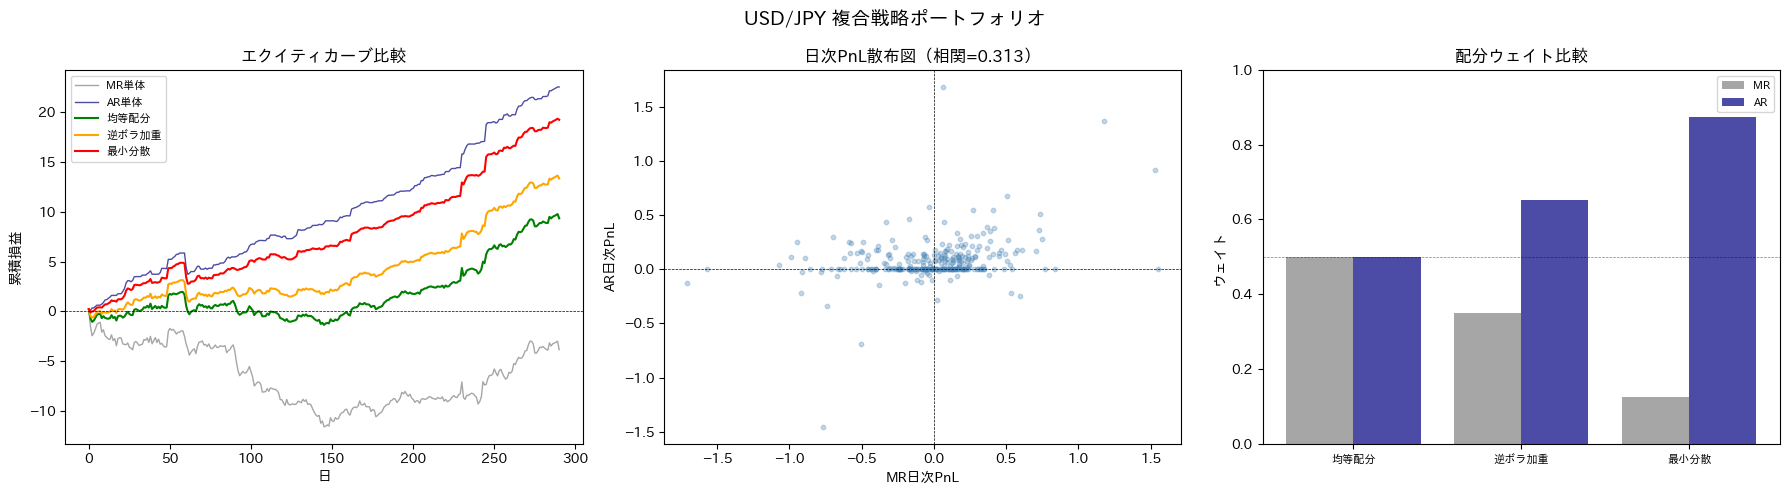

In [15]:
plot_portfolio_results(daily_usdjpy, pf_eq_usd, pf_iv_usd, pf_mv_usd,
                       "USD/JPY", weights_usdjpy)

### ETH/JPY 結果

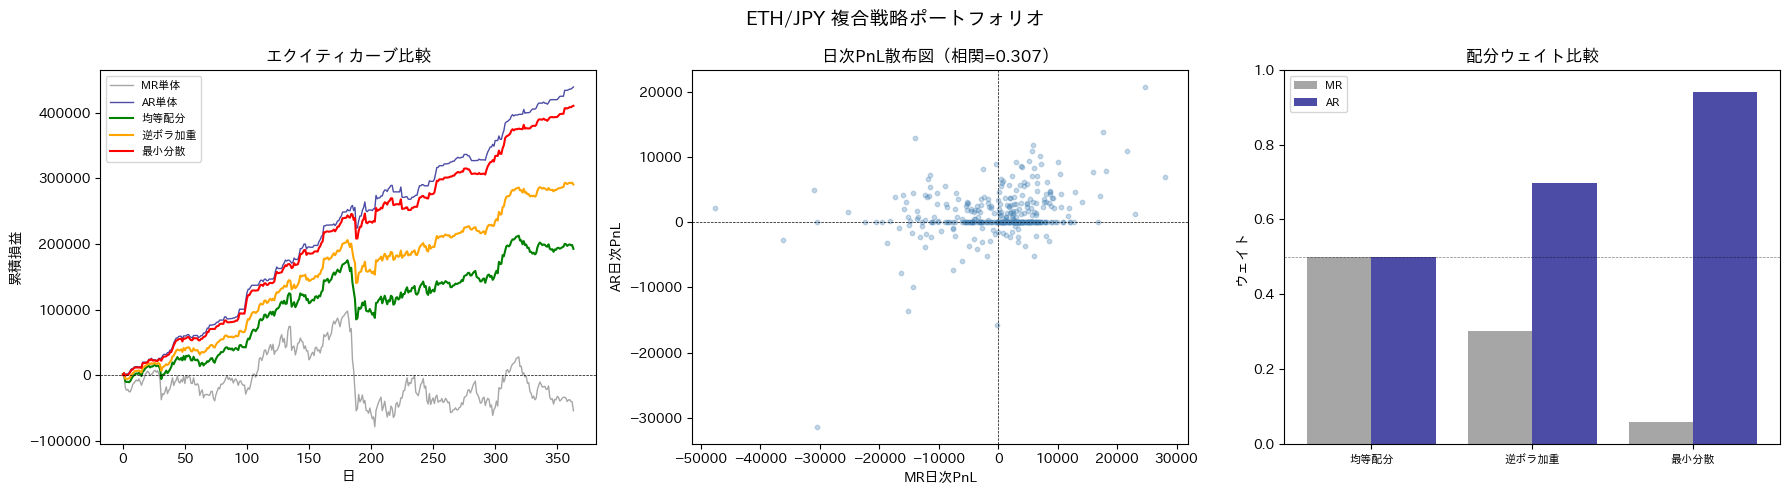

In [16]:
plot_portfolio_results(daily_eth, pf_eq_eth, pf_iv_eth, pf_mv_eth,
                       "ETH/JPY", weights_eth)

## 7. 比較サマリー

In [17]:
def print_full_summary(stats_list, symbol):
    print(f"\n{'='*70}")
    print(f"{symbol} 複合戦略ポートフォリオ 比較サマリー")
    print(f"{'='*70}")
    print(f"  {'条件':<20} {'総損益':>12} {'PF':>8} {'最大DD':>12} {'シャープ':>10}")
    print(f"  {'-'*65}")
    for s in stats_list:
        print(f"  {s['label']:<20} {s['total_pnl']:>12.4f} {s['pf']:>8.3f} "
              f"{s['max_dd']:>12.4f} {s['sharpe']:>10.3f}")
    print(f"{'='*70}")


print_full_summary([
    stats_mr_usd, stats_ar_usd,
    stats_eq_usd, stats_iv_usd, stats_mv_usd
], "USD/JPY")

print_full_summary([
    stats_mr_eth, stats_ar_eth,
    stats_eq_eth, stats_iv_eth, stats_mv_eth
], "ETH/JPY")


USD/JPY 複合戦略ポートフォリオ 比較サマリー
  条件                            総損益       PF         最大DD       シャープ
  -----------------------------------------------------------------
  MR単体                      -3.8420    0.910     -11.7870     -0.534
  AR単体                      22.5330    5.765      -2.1470      5.857
  均等配分                       9.3455    1.459      -3.3125      2.041
  逆ボラティリティ加重                13.3417    1.942      -2.1808      3.285
  最小分散（MPT）                 19.2381    3.621      -2.1060      5.136

ETH/JPY 複合戦略ポートフォリオ 比較サマリー
  条件                            総損益       PF         最大DD       シャープ
  -----------------------------------------------------------------
  MR単体                  -54161.4964    0.954 -176426.9976     -0.270
  AR単体                  439396.7797    3.523  -34326.6755      5.070
  均等配分                  192617.6416    1.329  -90213.9455      1.592
  逆ボラティリティ加重            290668.2702    1.769  -65567.0693      2.969
  最小分散（MPT）             410662.0474    3.046  -37